# Image generation using a conditional GAN

<a href="https://colab.research.google.com/github/DeepTrackAI/DeepTrack2/blob/develop/tutorials/2-examples/DTEx207_GAN_image_generation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# !pip install deeptrack  # Uncomment if running on Colab/Kaggle.

In this tutorial, you will train a conditional GAN to translate segmentation masks into realistic electron microscopy images. The dataset contains raw ssTEM images paired with segmentation maps that identify structures in the tissue.

You will prepare the dataset, build the generator and discriminator, train the GAN to generate images, and finally evaluate the model by comparing generated images with the ground truth.

## 1. Preparing the dataset

You start by downloading the dataset...

In [2]:
import os

if not os.path.exists("tissue_images_dataset"):
    os.system("git clone https://github.com/DeepTrackAI/tissue_images_dataset")

raw_path = os.path.join("tissue_images_dataset", "stack1", "raw")
seg_path = os.path.join("tissue_images_dataset", "stack1", "labels")

... and splitting them into training, validation, and test sets.



In [3]:
import deeptrack as dt

raw_paths = dt.sources.ImageFolder(root=raw_path)
seg_paths = dt.sources.ImageFolder(root=seg_path)
paths = dt.sources.Source(raw=raw_paths, label=seg_paths)
train_paths, val_paths, test_paths = \
    dt.sources.random_split(paths, [0.8, 0.1, 0.1])

train_srcs = train_paths.product(flip_ud=[True, False], flip_lr=[True, False])
val_srcs = val_paths.constants(flip_ud=False, flip_lr=False)
test_srcs = test_paths.constants(flip_ud=False, flip_lr=False)

sources = dt.sources.Join(train_srcs, val_srcs, test_srcs)

In [4]:
print(f"Raw images: {len(raw_paths)}")
print(f"Segmentation labels: {len(seg_paths)}")

Raw images: 20
Segmentation labels: 20


Next, a function to extract the membrane, background, and mitochondria channels from the segmentation masks is defined.

In [5]:
import numpy as np

def select_labels(class_labels):
    """Create a function to filter and remap labels in a segmentation map."""
    def inner(segmentation):
        seg = segmentation.copy()
        mask = seg * np.isin(seg, class_labels).astype(np.uint8)
        new_seg = (np.select([mask == c for c in class_labels],
                             np.arange(len(class_labels)) + 1)
                   .astype(np.uint8).squeeze())
        one_hot_encoded_seg = np.eye(len(class_labels) + 1)[new_seg]
        return one_hot_encoded_seg        
    return inner

### 1.1 Preprocessing the data

The microscopy images are normalized to the range [-1, 1]. Simple augmentations, such as horizontal and vertical flips, are applied to increase the variety of examples and improve generalization.

To make the training more efficient, the images are cropped into patches of 128 × 128 pixels. If you choose a larger crop size, your GAN may generalize better across tissue, but training will be slower and may need additional epochs.

In [6]:
import torch
im_pip = dt.LoadImage(sources.raw.path) >> dt.NormalizeMinMax(-1, 1)

seg_pip = (dt.LoadImage(sources.label.path)
           >> dt.Lambda(select_labels, class_labels=[255, 191]))
 
pip = ((seg_pip & im_pip) >> dt.FlipLR(sources.flip_lr)
       >> dt.FlipUD(sources.flip_ud) >> dt.Crop(crop=(128, 128, 3))
       >> dt.MoveAxis(2, 0) >> dt.pytorch.ToTensor(dtype=torch.float))

Next, the datasets for training, validation, and testing are defined. The parameter `replace=0.15` means that about 15% of the dataset is refreshed each epoch, exposing the model to new examples and improving generalization.

In [7]:
train_dataset = dt.pytorch.Dataset(pip, train_srcs, replace=True)
val_dataset = dt.pytorch.Dataset(pip, val_srcs, replace=True)
test_dataset = dt.pytorch.Dataset(pip, test_srcs, replace=True)

### 1.2 Visualizing the data

Before training, it is useful to inspect the dataset. Plotting a few examples lets you confirm that the raw images and segmentation masks are aligned and that preprocessing worked as expected

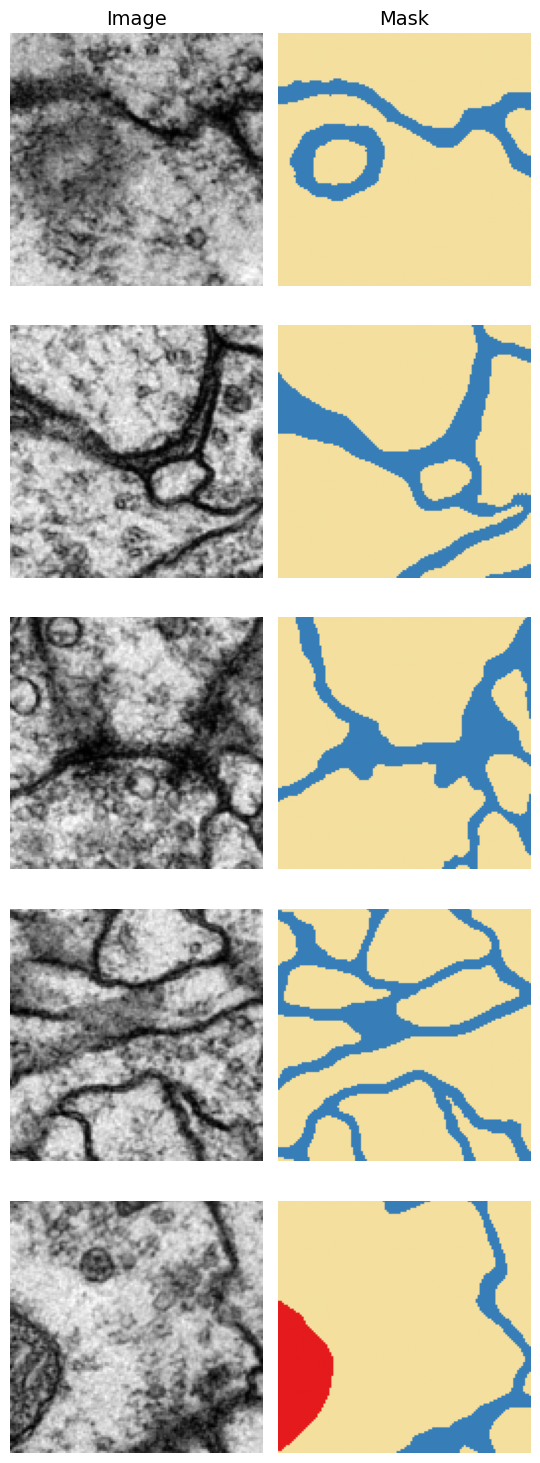

In [8]:
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

cmap = ListedColormap(["#377eb8", "#f4df9e", "#e41a1c"])

number_of_images = 5

fig, axs = plt.subplots(
    number_of_images, 2, figsize=(5.5, 3 * number_of_images)
)

for i in range(number_of_images):
    segmentation, image = train_dataset[i]

    axs[i, 0].imshow(image.permute(1, 2, 0), cmap="gray")
    axs[i, 0].axis("off")

    axs[i, 1].imshow(
        segmentation.argmax(dim=0).cpu().numpy(),
        cmap=cmap,
        vmin=0,
        vmax=segmentation.shape[0],
    )
    axs[i, 1].axis("off")

axs[0, 0].set_title("Image", fontsize=14)
axs[0, 1].set_title("Mask", fontsize=14)

plt.tight_layout()
plt.show()

## 2. Defining the model

The conditional GAN is composed of two submodels: a generator and a discriminator.

First, you determine which device will be used for computations.

In [9]:
def get_device():
    """Select device where to perform the computations."""
    if torch.cuda.is_available():
        return torch.device("cuda:0")
    elif torch.backends.mps.is_available():
        return torch.device("mps")
    else:
        return torch.device("cpu")

device = get_device()

print(f"Selected device: {device}")

Selected device: cuda:0


### 2.1 Building the generator

The generator is a U-Net model. It takes a segmentation mask (3 channels) plus two additional noise channels as input, and it is trained to produce a microscopy image as output. The segmentation mask ensures that the generated image has the correct structure (e.g. where the different regions are), while the noise channels introduce randomness that allow the generator to create realistic, varied textures. 
 
The final layer uses a Tanh activation function to keep the output values in the range [-1, 1].

In [10]:
import deeplay as dl
from torch.nn import InstanceNorm2d, LeakyReLU, Tanh

gen = dl.UNet2d(
    in_channels=5, channels=[32, 64, 128, 256, 512], out_channels=1,
)
gen["encoder", ..., "activation"].configure(LeakyReLU, negative_slope=0.2)
gen["decoder", ..., "activation#:-1"].configure(LeakyReLU, negative_slope=0.2)
gen["decoder", ..., "activation#-1"].configure(Tanh)
gen["decoder", "blocks", :-1].all.normalized(InstanceNorm2d)
gen[..., "blocks"].configure(order=["layer", "normalization", "activation"])
gen.build().to(device);

print(gen)

C:\Users\xgrmir\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\kornia\feature\lightglue.py:44: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  @torch.cuda.amp.custom_fwd(cast_inputs=torch.float32)


UNet2d(
  (encoder): ConvolutionalEncoder2d(
    (blocks): LayerList(
      (0): Conv2dBlock(
        (layer): Conv2d(5, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (activation): LeakyReLU(negative_slope=0.2)
      )
      (1): Conv2dBlock(
        (layer): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (activation): LeakyReLU(negative_slope=0.2)
      )
      (2): Conv2dBlock(
        (layer): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (activation): LeakyReLU(negative_slope=0.2)
      )
      (3): Conv2dBlock(
        (layer): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (activation): LeakyReLU(negative_slope=0.2)
      )
      (4): Conv2dBlock(
        (layer): Conv2d(256, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (activation): LeakyReLU(negative_slope=0.2)
      )
    )
    (postprocess): Identity()
  )
  (bottleneck): ConvolutionalNeuralNetwork(
    (bl

### 2.2 Building the discriminator
The discriminator is a convolutional neural network that receives both the mask and an image (real or generated). Its task is to decide whether the image is real or fake.

The last layer uses a Sigmoid activation so that the output can be interpreted as a probability.

In [11]:
from torch.nn import Sigmoid

disc = dl.ConvolutionalNeuralNetwork(
    in_channels=(3+1), hidden_channels=[8, 16, 32, 64], out_channels=1,
)
disc["blocks", ..., "layer"].configure(kernel_size=4, stride=2, padding=1)
disc["blocks", 1:-1].all.normalized(InstanceNorm2d)
disc["blocks", ..., "activation#-1"].configure(Sigmoid)
disc["blocks"].configure(order=["layer", "normalization", "activation"])
disc.build().to(device);

print(disc)

ConvolutionalNeuralNetwork(
  (blocks): LayerList(
    (0): Conv2dBlock(
      (layer): Conv2d(4, 8, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
      (activation): ReLU()
    )
    (1): Conv2dBlock(
      (layer): Conv2d(8, 16, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
      (normalization): InstanceNorm2d(16, eps=1e-05, momentum=0.1, affine=False, track_running_stats=False)
      (activation): ReLU()
    )
    (2): Conv2dBlock(
      (layer): Conv2d(16, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
      (normalization): InstanceNorm2d(32, eps=1e-05, momentum=0.1, affine=False, track_running_stats=False)
      (activation): ReLU()
    )
    (3): Conv2dBlock(
      (layer): Conv2d(32, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
      (normalization): InstanceNorm2d(64, eps=1e-05, momentum=0.1, affine=False, track_running_stats=False)
      (activation): ReLU()
    )
    (4): Conv2dBlock(
      (layer): Conv2d(64, 1, kernel_size=(4, 4), stride=(2, 2)

## 3. Training the GAN
### 3.1 Setting the loss functions and defining the optimizers

The GAN has two objectives. The discriminator learns to distinguish real images from generated ones, while the generator tries to both fool the discriminator and produce images that closely match the real targets.  

The generator loss has two parts. The adversarial loss comes from the discriminator’s predictions and indirectly encourages the generator to produce realistic images. The reconstruction loss (MAE) ensure the outputs match the ground truth.

In [12]:
loss_disc = torch.nn.MSELoss()

loss_recon_mse = torch.nn.MSELoss()
loss_recon_mae = torch.nn.L1Loss()

Next, the optimizers for the generator and discriminator are defined.

In [13]:
optim_gen = torch.optim.Adam(gen.parameters(), lr=.0002, betas=(.5, .999))
optim_disc = torch.optim.Adam(disc.parameters(), lr=.00005, betas=(.5, .999))

### 3.2 Defining the dataloaders
Dataloaders are created for the training, validation, and test sets.

In [14]:
train_loader = dl.DataLoader(train_dataset, batch_size=4, shuffle=True)
val_loader = dl.DataLoader(val_dataset, batch_size=2, shuffle=False)
test_loader = dl.DataLoader(test_dataset, batch_size=2, shuffle=False)

### 3.3 Defining the training process
Defining the training of the discriminator...

In [15]:
def train_disc(inputs, targets, optim_disc, loss_disc):
    """Train the discriminator."""
    optim_disc.zero_grad()

    # Compute real loss.
    disc_outputs_real = disc(torch.cat([inputs, targets], dim=1))
    labels_real = torch.ones_like(disc_outputs_real)
    disc_loss_real = loss_disc(disc_outputs_real, labels_real)

    # Compute fake loss.
    z = torch.randn(
        inputs.size(0), 2, inputs.size(2), inputs.size(3), device=inputs.device
    )  # 2 noise channels
    gen_outputs = gen(torch.cat([inputs, z], dim=1))
    disc_outputs_fake = disc(torch.cat([inputs, gen_outputs], dim=1))
    labels_fake = torch.zeros_like(disc_outputs_fake)
    disc_loss_fake = loss_disc(disc_outputs_fake, labels_fake)

    disc_loss = (disc_loss_real + disc_loss_fake) / 2
    disc_loss.backward()
    optim_disc.step()

    return disc_loss

.. and of the generator.

In [16]:
def train_gen(
    inputs,
    targets,
    optim_gen,
    loss_disc,
    loss_recon_mae,
    loss_recon_mse,
    recon_coef_mae=0.8,
    recon_coef_mse=1,
):
    """Train the generator."""
    optim_gen.zero_grad()

    z = torch.randn(
        inputs.size(0), 2, inputs.size(2), inputs.size(3), device=inputs.device
    )  # 2 noise channels
    gen_outputs = gen(torch.cat([inputs, z], dim=1))
    disc_outputs = disc(torch.cat([inputs, gen_outputs], dim=1))

    labels = torch.ones_like(disc_outputs)
    adv_loss = loss_disc(disc_outputs, labels)
    recon_loss_mae = loss_recon_mae(gen_outputs, targets)
    recon_loss_mse = loss_recon_mse(gen_outputs, targets)

    gen_loss = (
        adv_loss
        + recon_coef_mae * recon_loss_mae
        + recon_coef_mse * recon_loss_mse
    )
    gen_loss.backward()
    optim_gen.step()

    return gen_loss, adv_loss, recon_loss_mae, recon_loss_mse

### 3.4 Evaluating the model

During training, or after it is complete, you can evaluate the model on validation or test data. The mask, the generated image, and the ground truth image are shown side by side.  

This visualization allows you to see whether the GAN has learned to produce realistic microscopy images that match the segmentation masks.


In [17]:
def evaluate_model(input, target):
    """Evaluate model on validation or test data."""
    gen.eval()
    with torch.no_grad():
        z = torch.randn(
            input.size(0), 2, input.size(2), input.size(3), device=input.device
        )
        prediction = gen(torch.cat([input, z], dim=1).to(device))
    gen.train()

    fig, axs = plt.subplots(2, 3, figsize=(10, 8))

    axs[0, 0].imshow(
        input[0].argmax(dim=0).cpu().numpy(),
        cmap=cmap,
        vmin=0,
        vmax=input.shape[1],
    )
    axs[0, 0].axis("off")

    axs[0, 1].imshow(prediction[0].permute(1, 2, 0).cpu(), cmap="gray")
    axs[0, 1].axis("off")

    axs[0, 2].imshow(target[0].permute(1, 2, 0).cpu(), cmap="gray")
    axs[0, 2].axis("off")

    axs[1, 0].imshow(
        input[1].argmax(dim=0).cpu().numpy(),
        cmap=cmap,
        vmin=0,
        vmax=input.shape[1],
    )
    axs[1, 0].axis("off")

    axs[1, 1].imshow(prediction[1].permute(1, 2, 0).cpu(), cmap="gray")
    axs[1, 1].axis("off")

    axs[1, 2].imshow(target[1].permute(1, 2, 0).cpu(), cmap="gray")
    axs[1, 2].axis("off")

    plt.tight_layout()
    plt.show()
    plt.close(fig)

### 3.5 Training loop

The training loop iterates over 250 epochs. For each batch, the discriminator is trained first, followed by the generator.  

After each epoch, average losses are computed and printed, giving you an overview of training progress. Periodically, the model is evaluated on the validation set to visually inspect its performance.


Epoch 1/250
----------
Batch 1/16 : Total Generator Loss: 0.8238, Discriminator Loss: 0.2622
Batch 8/16 : Total Generator Loss: 0.5324, Discriminator Loss: 0.2536
Batch 15/16 : Total Generator Loss: 0.5676, Discriminator Loss: 0.2565
----------
Epoch 1/250 : Discriminator Loss: 0.2575, Total Generator Loss: 0.5891, Reconstruction Loss MAE: 0.2822, Reconstruction Loss MSE: 0.1264, Time taken: 0:00:08.861867


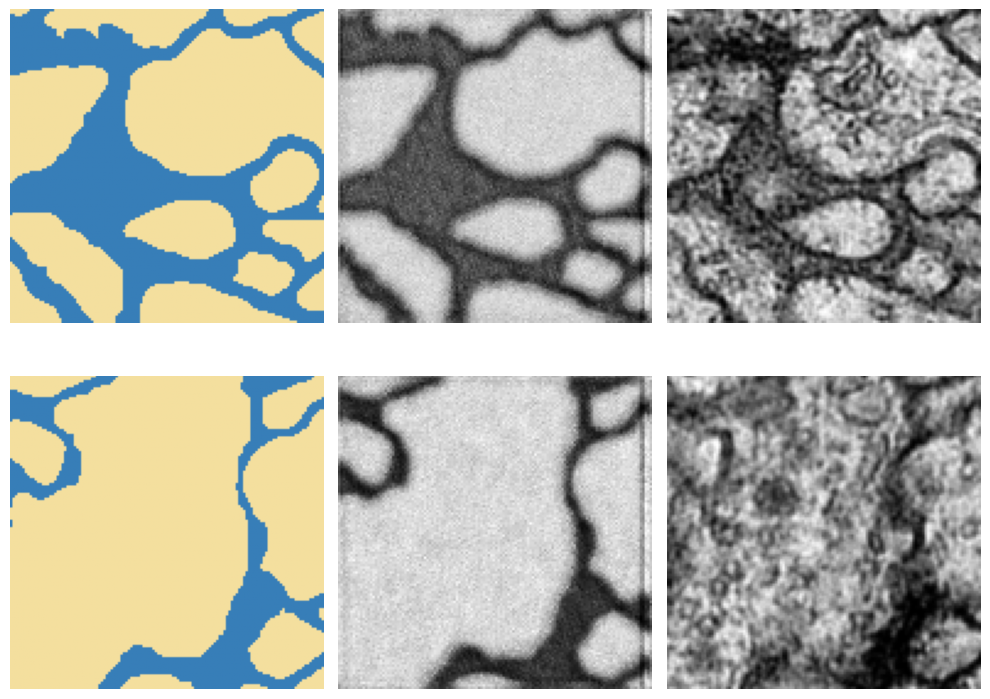


Epoch 2/250
----------
Batch 1/16 : Total Generator Loss: 0.5560, Discriminator Loss: 0.2543
Batch 8/16 : Total Generator Loss: 0.5506, Discriminator Loss: 0.2548
Batch 15/16 : Total Generator Loss: 0.5639, Discriminator Loss: 0.2540
----------
Epoch 2/250 : Discriminator Loss: 0.2556, Total Generator Loss: 0.5654, Reconstruction Loss MAE: 0.2606, Reconstruction Loss MSE: 0.1054, Time taken: 0:00:07.687274

Epoch 3/250
----------
Batch 1/16 : Total Generator Loss: 0.5397, Discriminator Loss: 0.2570
Batch 8/16 : Total Generator Loss: 0.5720, Discriminator Loss: 0.2542
Batch 15/16 : Total Generator Loss: 0.5647, Discriminator Loss: 0.2510
----------
Epoch 3/250 : Discriminator Loss: 0.2525, Total Generator Loss: 0.5575, Reconstruction Loss MAE: 0.2513, Reconstruction Loss MSE: 0.1004, Time taken: 0:00:07.885386

Epoch 4/250
----------
Batch 1/16 : Total Generator Loss: 0.5360, Discriminator Loss: 0.2523
Batch 8/16 : Total Generator Loss: 0.5866, Discriminator Loss: 0.2591
Batch 15/16 : 

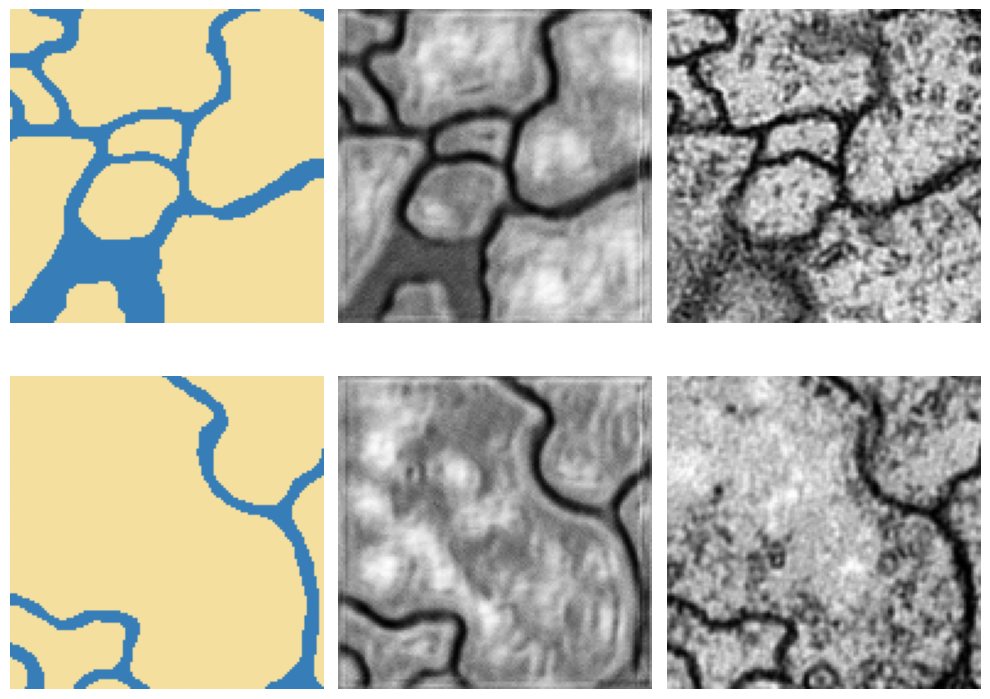


Epoch 27/250
----------
Batch 1/16 : Total Generator Loss: 0.6081, Discriminator Loss: 0.2401
Batch 8/16 : Total Generator Loss: 0.6112, Discriminator Loss: 0.2301
Batch 15/16 : Total Generator Loss: 0.6426, Discriminator Loss: 0.2405
----------
Epoch 27/250 : Discriminator Loss: 0.2387, Total Generator Loss: 0.6242, Reconstruction Loss MAE: 0.2803, Reconstruction Loss MSE: 0.1244, Time taken: 0:00:08.572898

Epoch 28/250
----------
Batch 1/16 : Total Generator Loss: 0.6262, Discriminator Loss: 0.2296
Batch 8/16 : Total Generator Loss: 0.6030, Discriminator Loss: 0.2651
Batch 15/16 : Total Generator Loss: 0.6350, Discriminator Loss: 0.2490
----------
Epoch 28/250 : Discriminator Loss: 0.2412, Total Generator Loss: 0.6268, Reconstruction Loss MAE: 0.2816, Reconstruction Loss MSE: 0.1281, Time taken: 0:00:08.552614

Epoch 29/250
----------
Batch 1/16 : Total Generator Loss: 0.6562, Discriminator Loss: 0.2347
Batch 8/16 : Total Generator Loss: 0.6094, Discriminator Loss: 0.2381
Batch 15/

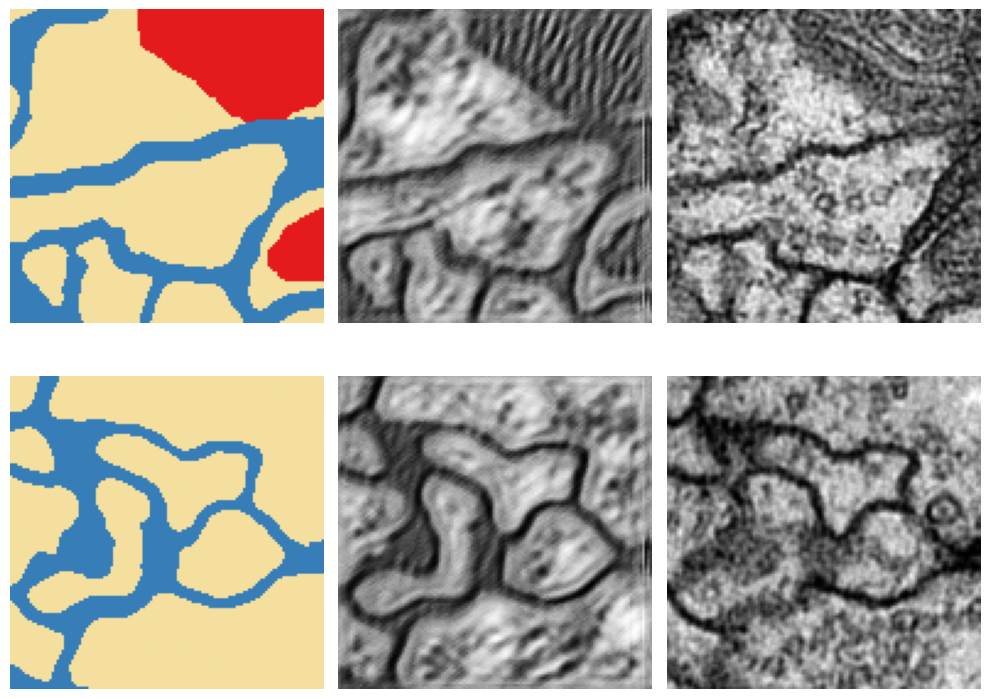


Epoch 52/250
----------
Batch 1/16 : Total Generator Loss: 0.6571, Discriminator Loss: 0.2445
Batch 8/16 : Total Generator Loss: 0.7113, Discriminator Loss: 0.2376
Batch 15/16 : Total Generator Loss: 0.6723, Discriminator Loss: 0.2404
----------
Epoch 52/250 : Discriminator Loss: 0.2417, Total Generator Loss: 0.6626, Reconstruction Loss MAE: 0.3024, Reconstruction Loss MSE: 0.1487, Time taken: 0:00:08.053521

Epoch 53/250
----------
Batch 1/16 : Total Generator Loss: 0.6800, Discriminator Loss: 0.2296
Batch 8/16 : Total Generator Loss: 0.6856, Discriminator Loss: 0.2469
Batch 15/16 : Total Generator Loss: 0.6871, Discriminator Loss: 0.2418
----------
Epoch 53/250 : Discriminator Loss: 0.2427, Total Generator Loss: 0.6617, Reconstruction Loss MAE: 0.3038, Reconstruction Loss MSE: 0.1499, Time taken: 0:00:08.050050

Epoch 54/250
----------
Batch 1/16 : Total Generator Loss: 0.6285, Discriminator Loss: 0.2463
Batch 8/16 : Total Generator Loss: 0.6591, Discriminator Loss: 0.2359
Batch 15/

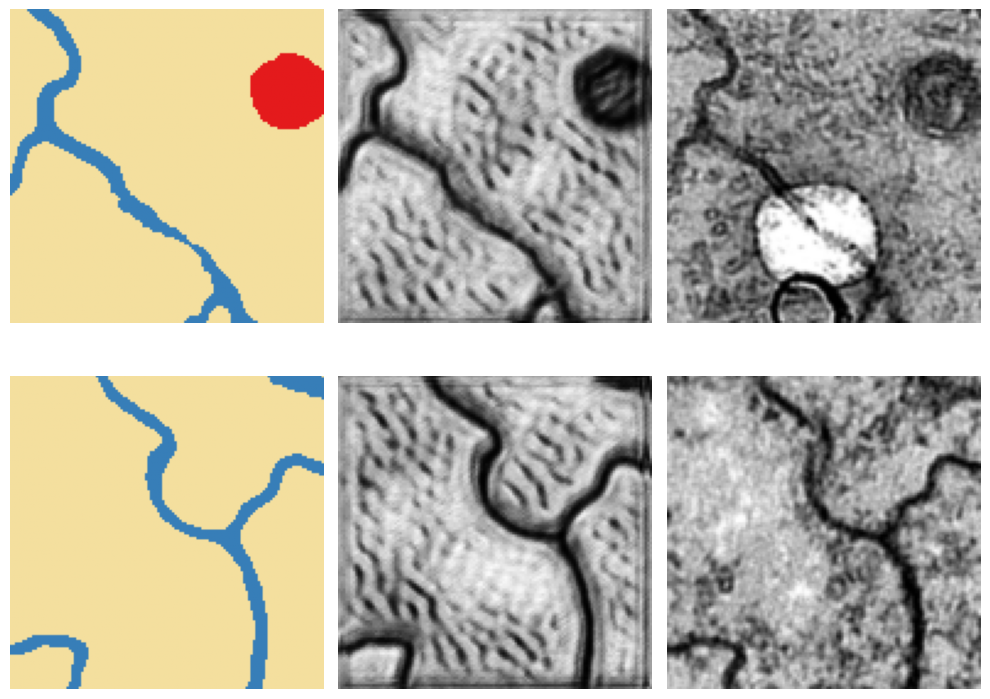


Epoch 77/250
----------
Batch 1/16 : Total Generator Loss: 0.6500, Discriminator Loss: 0.2539
Batch 8/16 : Total Generator Loss: 0.6999, Discriminator Loss: 0.2451
Batch 15/16 : Total Generator Loss: 0.6524, Discriminator Loss: 0.2455
----------
Epoch 77/250 : Discriminator Loss: 0.2454, Total Generator Loss: 0.6780, Reconstruction Loss MAE: 0.3175, Reconstruction Loss MSE: 0.1626, Time taken: 0:00:08.344144

Epoch 78/250
----------
Batch 1/16 : Total Generator Loss: 0.7389, Discriminator Loss: 0.2322
Batch 8/16 : Total Generator Loss: 0.6567, Discriminator Loss: 0.2469
Batch 15/16 : Total Generator Loss: 0.6806, Discriminator Loss: 0.2628
----------
Epoch 78/250 : Discriminator Loss: 0.2488, Total Generator Loss: 0.6818, Reconstruction Loss MAE: 0.3171, Reconstruction Loss MSE: 0.1657, Time taken: 0:00:08.445584

Epoch 79/250
----------
Batch 1/16 : Total Generator Loss: 0.7200, Discriminator Loss: 0.2299
Batch 8/16 : Total Generator Loss: 0.6620, Discriminator Loss: 0.2227
Batch 15/

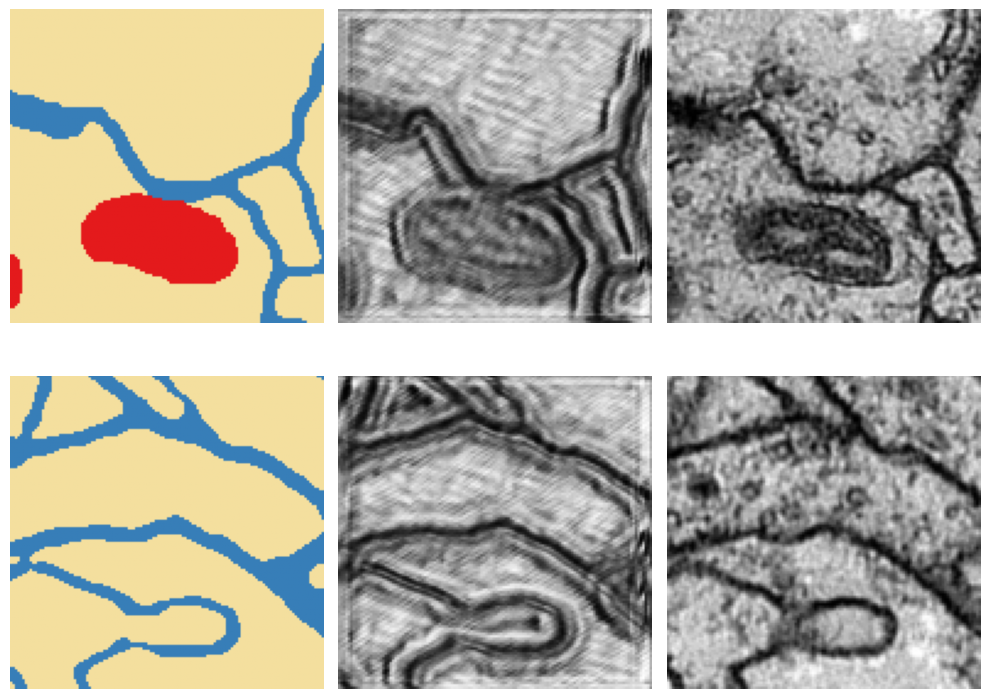


Epoch 102/250
----------
Batch 1/16 : Total Generator Loss: 0.6638, Discriminator Loss: 0.2562
Batch 8/16 : Total Generator Loss: 0.6778, Discriminator Loss: 0.2473
Batch 15/16 : Total Generator Loss: 0.6534, Discriminator Loss: 0.2366
----------
Epoch 102/250 : Discriminator Loss: 0.2421, Total Generator Loss: 0.6717, Reconstruction Loss MAE: 0.3113, Reconstruction Loss MSE: 0.1562, Time taken: 0:00:08.005686

Epoch 103/250
----------
Batch 1/16 : Total Generator Loss: 0.7173, Discriminator Loss: 0.2320
Batch 8/16 : Total Generator Loss: 0.6731, Discriminator Loss: 0.2456
Batch 15/16 : Total Generator Loss: 0.6678, Discriminator Loss: 0.2473
----------
Epoch 103/250 : Discriminator Loss: 0.2406, Total Generator Loss: 0.6771, Reconstruction Loss MAE: 0.3175, Reconstruction Loss MSE: 0.1614, Time taken: 0:00:08.036915

Epoch 104/250
----------
Batch 1/16 : Total Generator Loss: 0.6457, Discriminator Loss: 0.2515
Batch 8/16 : Total Generator Loss: 0.7229, Discriminator Loss: 0.2401
Batc

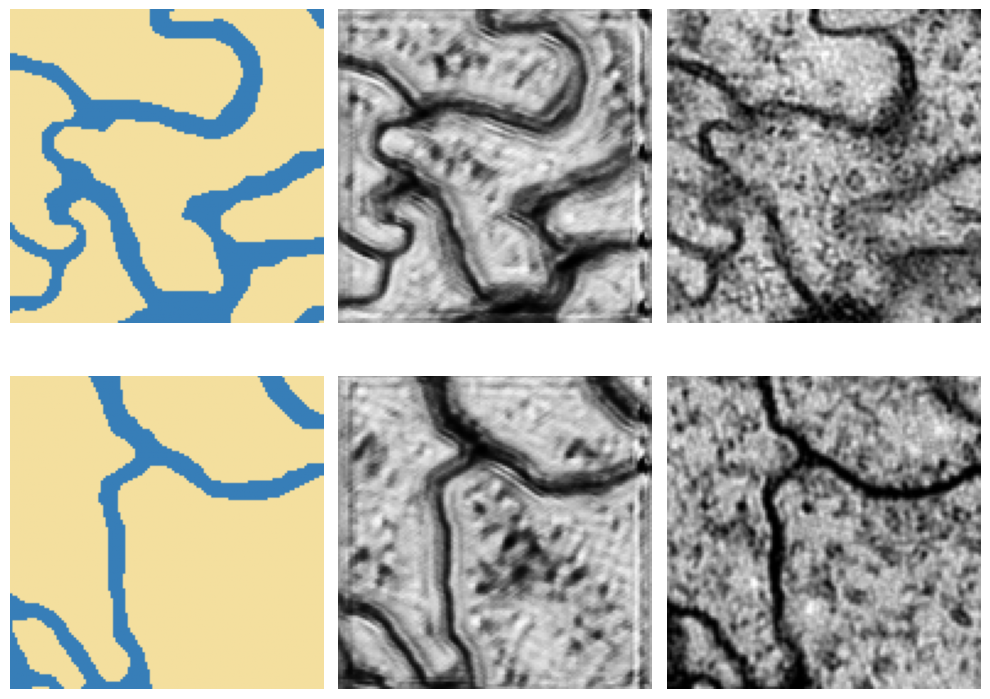


Epoch 127/250
----------
Batch 1/16 : Total Generator Loss: 0.7038, Discriminator Loss: 0.2226
Batch 8/16 : Total Generator Loss: 0.6688, Discriminator Loss: 0.2479
Batch 15/16 : Total Generator Loss: 0.6817, Discriminator Loss: 0.2420
----------
Epoch 127/250 : Discriminator Loss: 0.2467, Total Generator Loss: 0.6763, Reconstruction Loss MAE: 0.3196, Reconstruction Loss MSE: 0.1648, Time taken: 0:00:08.193371

Epoch 128/250
----------
Batch 1/16 : Total Generator Loss: 0.6760, Discriminator Loss: 0.2569
Batch 8/16 : Total Generator Loss: 0.6813, Discriminator Loss: 0.2430
Batch 15/16 : Total Generator Loss: 0.7379, Discriminator Loss: 0.2476
----------
Epoch 128/250 : Discriminator Loss: 0.2523, Total Generator Loss: 0.6954, Reconstruction Loss MAE: 0.3263, Reconstruction Loss MSE: 0.1740, Time taken: 0:00:08.193861

Epoch 129/250
----------
Batch 1/16 : Total Generator Loss: 0.6912, Discriminator Loss: 0.2562
Batch 8/16 : Total Generator Loss: 0.7279, Discriminator Loss: 0.2428
Batc

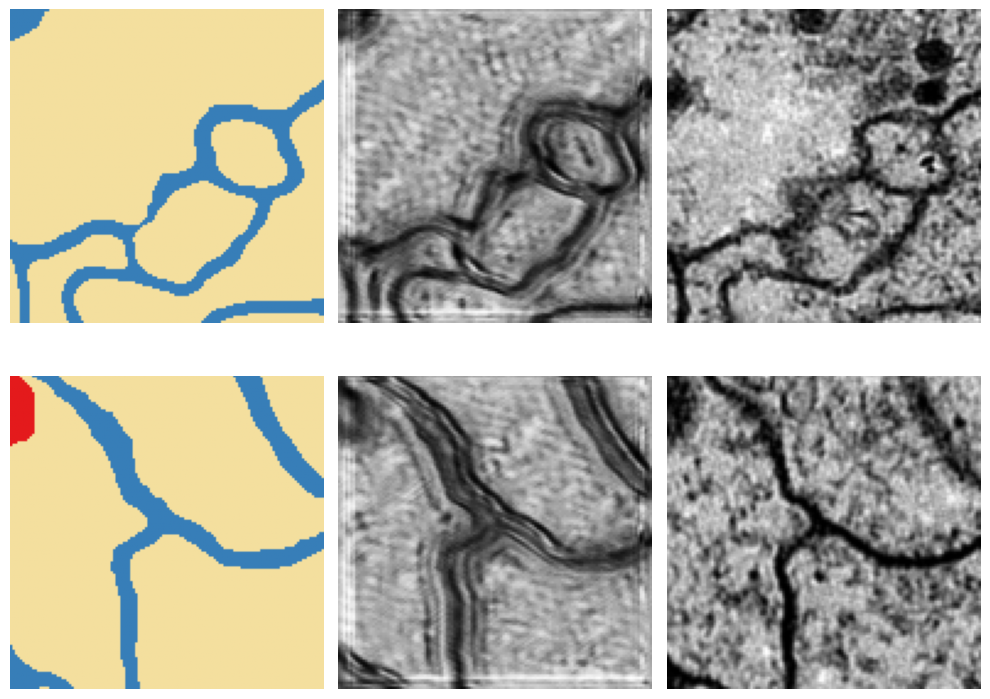


Epoch 152/250
----------
Batch 1/16 : Total Generator Loss: 0.6686, Discriminator Loss: 0.2407
Batch 8/16 : Total Generator Loss: 0.6745, Discriminator Loss: 0.2416
Batch 15/16 : Total Generator Loss: 0.6744, Discriminator Loss: 0.2550
----------
Epoch 152/250 : Discriminator Loss: 0.2401, Total Generator Loss: 0.6860, Reconstruction Loss MAE: 0.3208, Reconstruction Loss MSE: 0.1658, Time taken: 0:00:07.952366

Epoch 153/250
----------
Batch 1/16 : Total Generator Loss: 0.7295, Discriminator Loss: 0.2176
Batch 8/16 : Total Generator Loss: 0.6798, Discriminator Loss: 0.2350
Batch 15/16 : Total Generator Loss: 0.6908, Discriminator Loss: 0.2370
----------
Epoch 153/250 : Discriminator Loss: 0.2426, Total Generator Loss: 0.6878, Reconstruction Loss MAE: 0.3187, Reconstruction Loss MSE: 0.1640, Time taken: 0:00:07.995535

Epoch 154/250
----------
Batch 1/16 : Total Generator Loss: 0.6868, Discriminator Loss: 0.2438
Batch 8/16 : Total Generator Loss: 0.6547, Discriminator Loss: 0.2696
Batc

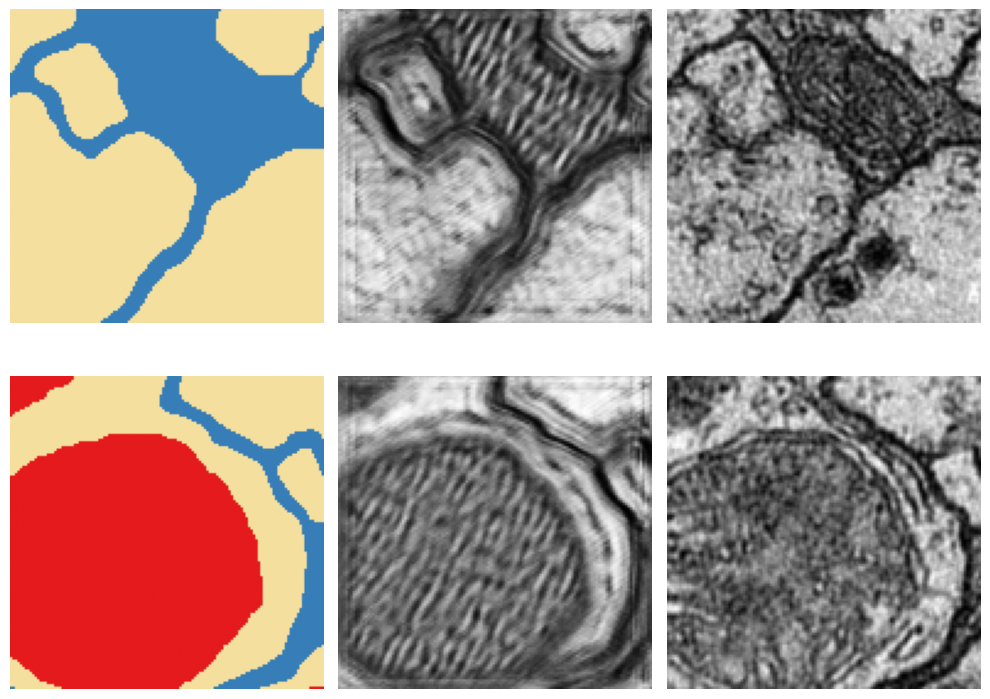


Epoch 177/250
----------
Batch 1/16 : Total Generator Loss: 0.7072, Discriminator Loss: 0.2383
Batch 8/16 : Total Generator Loss: 0.7266, Discriminator Loss: 0.2357
Batch 15/16 : Total Generator Loss: 0.6931, Discriminator Loss: 0.2261
----------
Epoch 177/250 : Discriminator Loss: 0.2438, Total Generator Loss: 0.7002, Reconstruction Loss MAE: 0.3294, Reconstruction Loss MSE: 0.1725, Time taken: 0:00:07.995241

Epoch 178/250
----------
Batch 1/16 : Total Generator Loss: 0.7175, Discriminator Loss: 0.2570
Batch 8/16 : Total Generator Loss: 0.7336, Discriminator Loss: 0.2424
Batch 15/16 : Total Generator Loss: 0.7106, Discriminator Loss: 0.2456
----------
Epoch 178/250 : Discriminator Loss: 0.2522, Total Generator Loss: 0.7088, Reconstruction Loss MAE: 0.3351, Reconstruction Loss MSE: 0.1806, Time taken: 0:00:08.220526

Epoch 179/250
----------
Batch 1/16 : Total Generator Loss: 0.6982, Discriminator Loss: 0.2441
Batch 8/16 : Total Generator Loss: 0.6524, Discriminator Loss: 0.2544
Batc

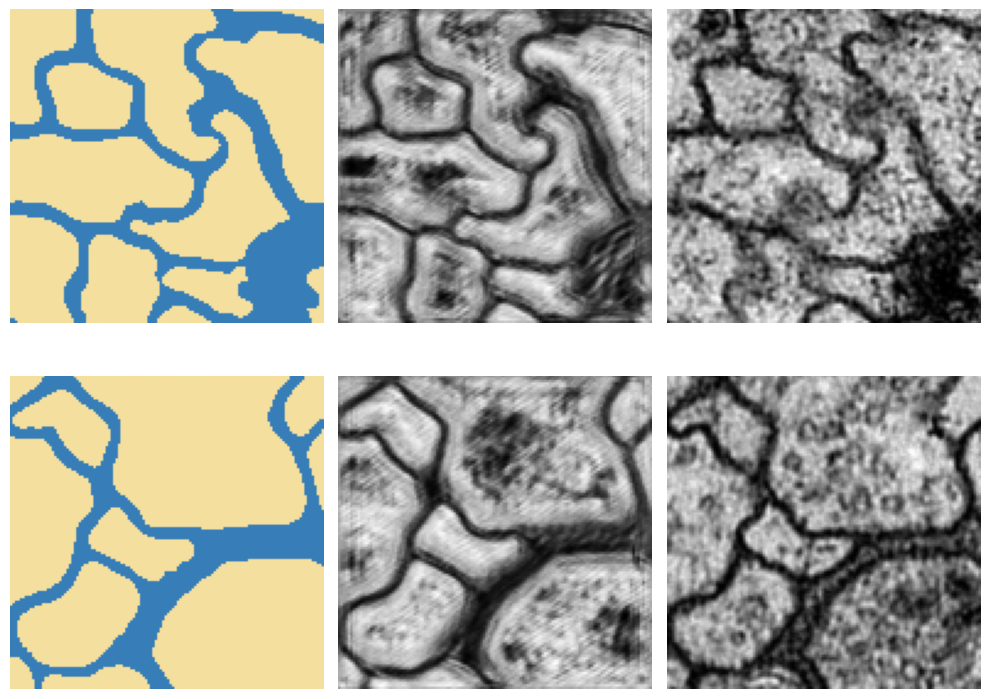


Epoch 202/250
----------
Batch 1/16 : Total Generator Loss: 0.6812, Discriminator Loss: 0.2354
Batch 8/16 : Total Generator Loss: 0.7150, Discriminator Loss: 0.2494
Batch 15/16 : Total Generator Loss: 0.7069, Discriminator Loss: 0.2274
----------
Epoch 202/250 : Discriminator Loss: 0.2436, Total Generator Loss: 0.6981, Reconstruction Loss MAE: 0.3268, Reconstruction Loss MSE: 0.1730, Time taken: 0:00:08.704119

Epoch 203/250
----------
Batch 1/16 : Total Generator Loss: 0.6943, Discriminator Loss: 0.2615
Batch 8/16 : Total Generator Loss: 0.6990, Discriminator Loss: 0.2380
Batch 15/16 : Total Generator Loss: 0.7070, Discriminator Loss: 0.2305
----------
Epoch 203/250 : Discriminator Loss: 0.2492, Total Generator Loss: 0.6947, Reconstruction Loss MAE: 0.3267, Reconstruction Loss MSE: 0.1734, Time taken: 0:00:08.488478

Epoch 204/250
----------
Batch 1/16 : Total Generator Loss: 0.6966, Discriminator Loss: 0.2332
Batch 8/16 : Total Generator Loss: 0.7044, Discriminator Loss: 0.2424
Batc

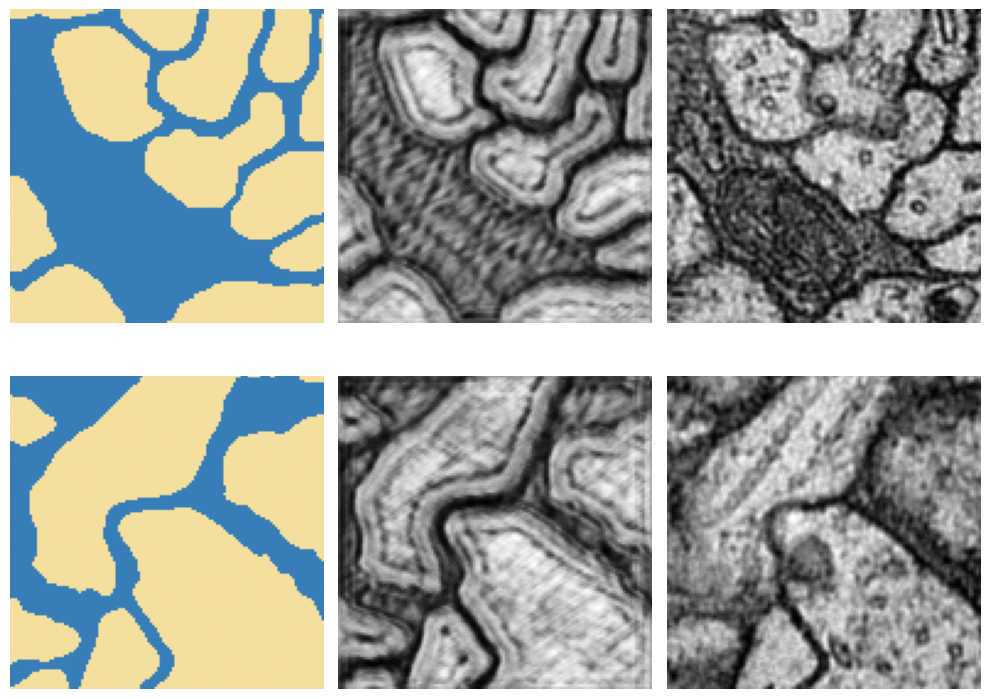


Epoch 227/250
----------
Batch 1/16 : Total Generator Loss: 0.7205, Discriminator Loss: 0.2185
Batch 8/16 : Total Generator Loss: 0.6912, Discriminator Loss: 0.2375
Batch 15/16 : Total Generator Loss: 0.7013, Discriminator Loss: 0.2770
----------
Epoch 227/250 : Discriminator Loss: 0.2370, Total Generator Loss: 0.7027, Reconstruction Loss MAE: 0.3234, Reconstruction Loss MSE: 0.1672, Time taken: 0:00:08.065785

Epoch 228/250
----------
Batch 1/16 : Total Generator Loss: 0.6912, Discriminator Loss: 0.2604
Batch 8/16 : Total Generator Loss: 0.7080, Discriminator Loss: 0.2362
Batch 15/16 : Total Generator Loss: 0.6988, Discriminator Loss: 0.2363
----------
Epoch 228/250 : Discriminator Loss: 0.2512, Total Generator Loss: 0.7008, Reconstruction Loss MAE: 0.3271, Reconstruction Loss MSE: 0.1734, Time taken: 0:00:08.045871

Epoch 229/250
----------
Batch 1/16 : Total Generator Loss: 0.7273, Discriminator Loss: 0.2362
Batch 8/16 : Total Generator Loss: 0.7275, Discriminator Loss: 0.2339
Batc

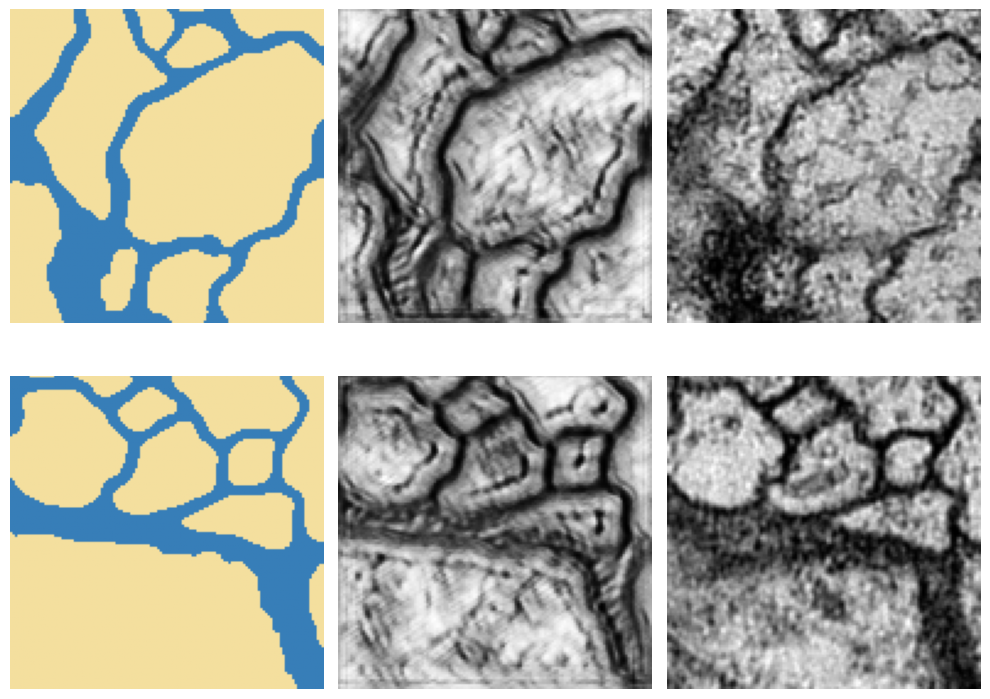

In [18]:
import time
from datetime import timedelta

epochs = 250

disc_losses, gen_losses, recon_losses_mae, recon_losses_mse = [], [], [], []
for epoch in range(epochs):
    start_time = time.time()
    print("\n" + f"Epoch {epoch + 1}/{epochs}" + "\n" + "-" * 10)

    disc_loss_epoch, gen_loss_epoch = [], []
    recon_loss_mae_epoch, recon_loss_mse_epoch = [], []
    for i, (inputs, targets) in enumerate(train_loader, 0):
        inputs, targets = inputs.to(device), targets.to(device)

        # 1. Train the discriminator.
        disc_loss = train_disc(inputs, targets, optim_disc, loss_disc)

        # 2. Train the generator.
        gen_loss, adv_loss, recon_loss_mae, recon_loss_mse = train_gen(
            inputs,
            targets,
            optim_gen,
            loss_disc,
            loss_recon_mae,
            loss_recon_mse,
        )

        if i % 7 == 0:
            print(
                f"Batch {i + 1}/{len(train_loader)} : "
                f"Total Generator Loss: {gen_loss.item():.4f}, "
                f"Discriminator Loss: {disc_loss.item():.4f}"
            )

        disc_loss_epoch.append(disc_loss.item())
        gen_loss_epoch.append(gen_loss.item())
        recon_loss_mae_epoch.append(recon_loss_mae.item())
        recon_loss_mse_epoch.append(recon_loss_mse.item())

    end_time = time.time()

    disc_losses.append(np.mean(disc_loss_epoch))
    gen_losses.append(np.mean(gen_loss_epoch))
    recon_losses_mae.append(np.mean(recon_loss_mae_epoch))
    recon_losses_mse.append(np.mean(recon_loss_mse_epoch))

    print(
        f"-" * 10 + "\n" + f"Epoch {epoch + 1}/{epochs} : "
        f"Discriminator Loss: {disc_losses[-1]:.4f}, "
        f"Total Generator Loss: {gen_losses[-1]:.4f}, "
        f"Reconstruction Loss MAE: {recon_losses_mae[-1]:.4f}, "
        f"Reconstruction Loss MSE: {recon_losses_mse[-1]:.4f}, "
        f"Time taken: {timedelta(seconds=end_time - start_time)}"
    )

    if epoch % 25 == 0 or epoch + 1 == epochs:
        for i, (val_input, val_target) in enumerate(val_loader, 0):
            evaluate_model(val_input, val_target)

### full-size images and fewer epochs?

## 4. Evaluating the GAN on the test data

After training, you can evaluate the GAN on the test set to see how well it generalizes to unseen images. The results show the input mask, the generated image, and the corresponding ground truth image side by side.

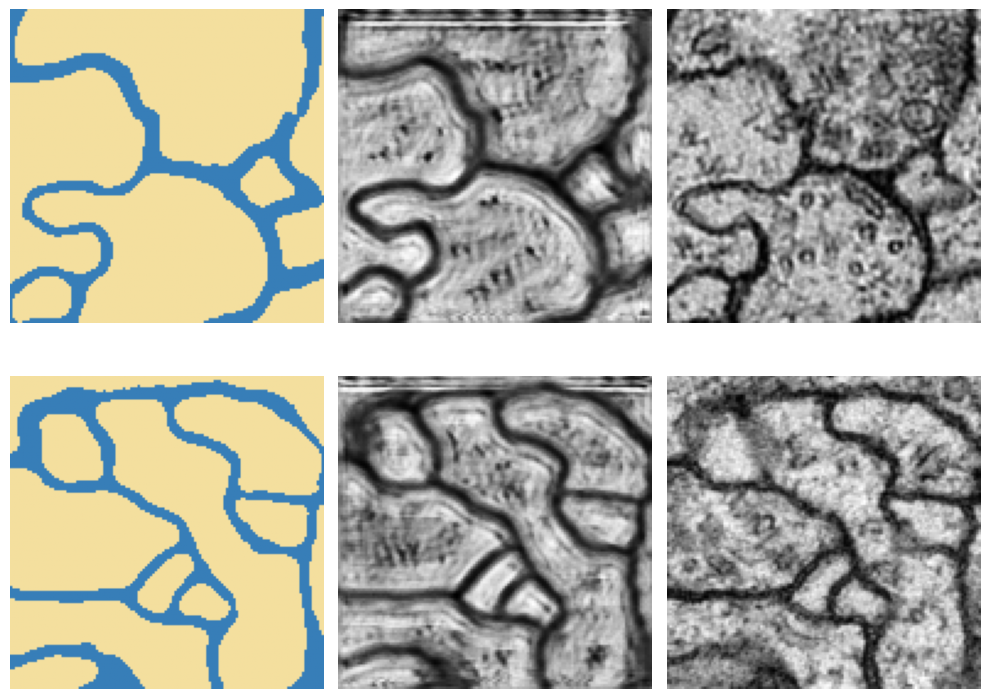

In [19]:
for i, (test_input, test_target) in enumerate(test_loader, 0):
    evaluate_model(test_input, test_target)